# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [ ]:
# Advantages to showing nitrate and phosphate as area plots allows the viewer to quickly see broad patterns, like wheter both nutrients are generally increasing or decreasing together.  The disadvantage is that area plots make exact comparison harder, especially when we're comparing two separate variables rather than parts of a whole.  Using line graphs instead of filled areas, adding clear title, keeping the same x-axis scale, reducing clutter like using light grid, readable legend, and avoiding heavy shading are some methods to improve the presentation.

In [12]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

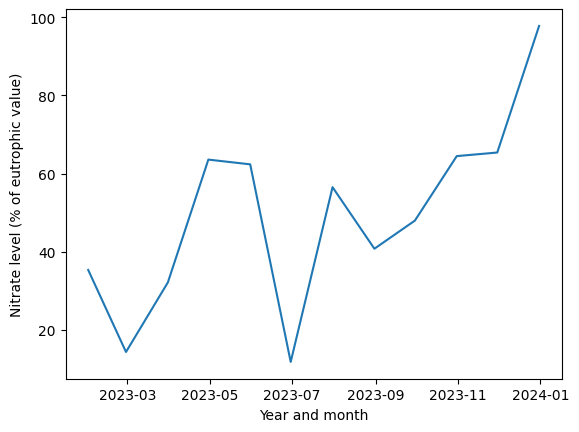

In [3]:
numdates = 12
np.random.seed(0)

time_series = 100 * (np.random.normal(size=numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023-01-01', end='2024-01-01', freq='ME')

ax = sns.lineplot(x=datearray, y=time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

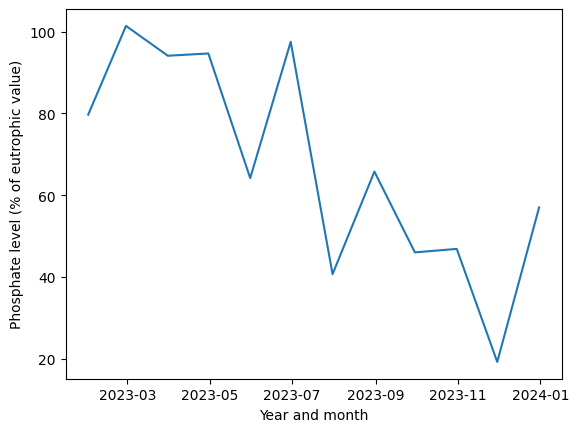

In [4]:
np.random.seed(1)
time_series_2 = 100 * (1 - (np.random.normal(size=numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023-01-31', periods=numdates, freq='ME')

ax = sns.lineplot(x=datearray, y=time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

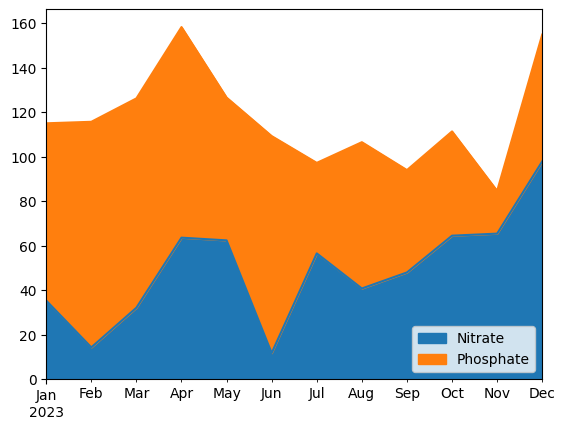

In [8]:
datearray = pd.date_range(start='2023-01-31', periods=numdates, freq='ME')
aa = pd.DataFrame({
    'Nitrate': time_series,
    'Phosphate': time_series_2
}, index=datearray)
aa.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

                          age       bmi  blood_pressure  cholesterol  \
age                  1.000000 -0.039413       -0.145823    -0.056075   
bmi                 -0.039413  1.000000       -0.037166     0.063924   
blood_pressure      -0.145823 -0.037166        1.000000    -0.187027   
cholesterol         -0.056075  0.063924       -0.187027     1.000000   
diabetes_risk_score  0.024851  0.024664       -0.158997     0.140518   

                     diabetes_risk_score  
age                             0.024851  
bmi                             0.024664  
blood_pressure                 -0.158997  
cholesterol                     0.140518  
diabetes_risk_score             1.000000  


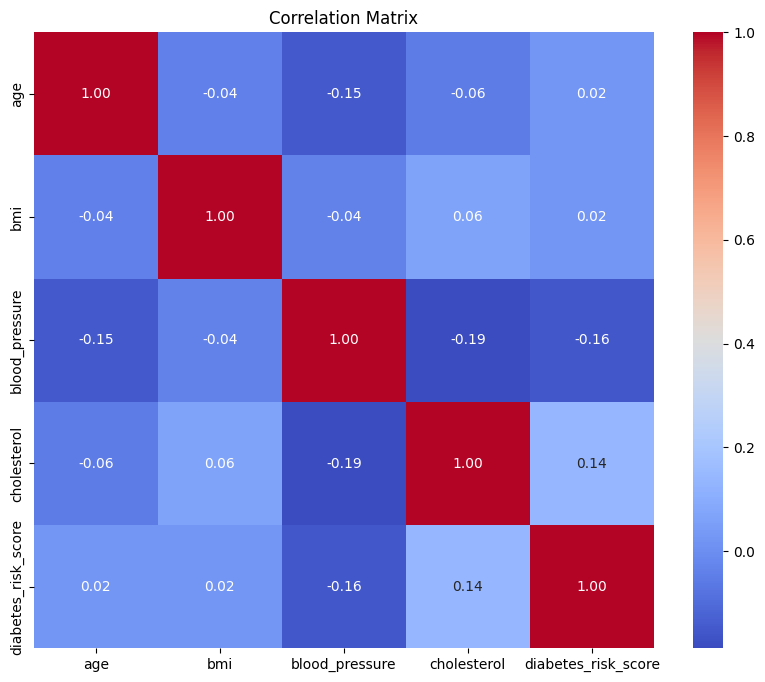

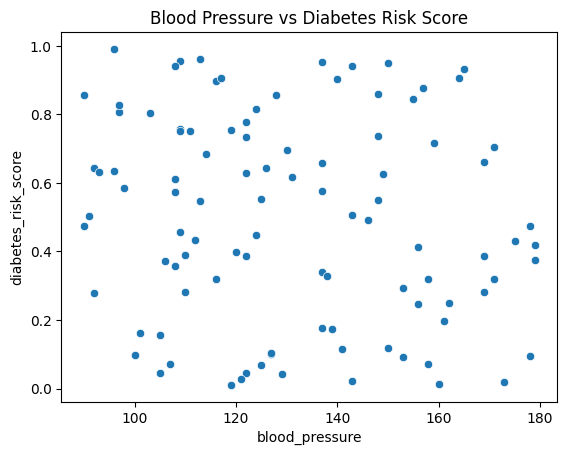

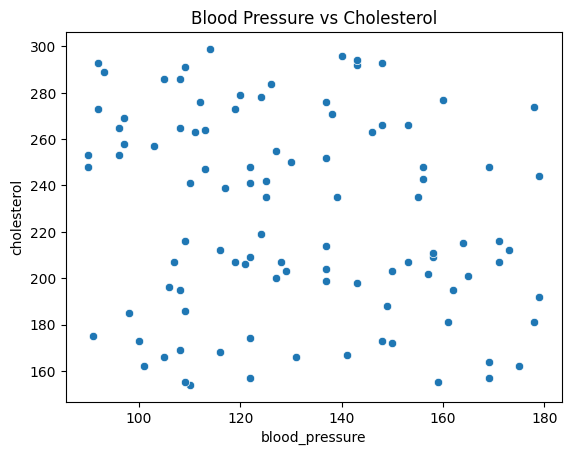

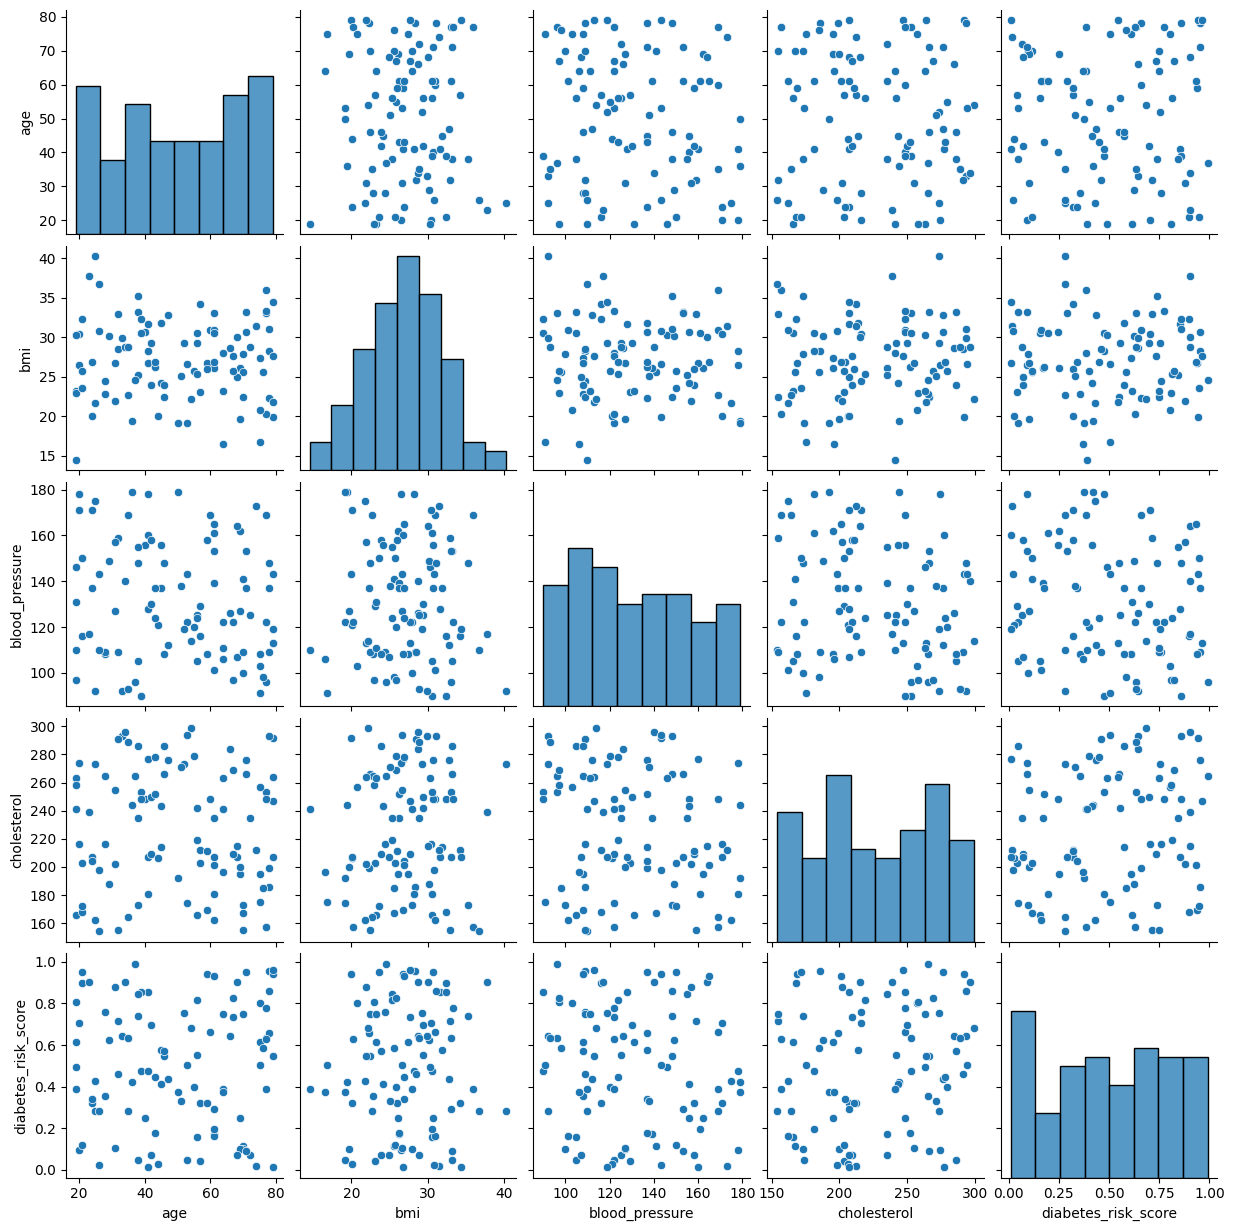

In [16]:
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

#Correlation 
corr = df.corr()
print(corr)

plt.figure(figsize= (10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#Scatter plot blood pressure vs risk
sns.scatterplot(data=df, x="blood_pressure", y="diabetes_risk_score")
plt.title("Blood Pressure vs Diabetes Risk Score")
plt.show()

#Scatter plot blood pressure vs cholesterol
sns.scatterplot(data=df, x="blood_pressure", y="cholesterol")
plt.title("Blood Pressure vs Cholesterol")
plt.show()

#pair plot
sns.pairplot(df)
plt.show()

In [ ]:
#Conclusion: The bivariate analysis showed generally weak relationships among age, BMI, blood pressure, cholesterol, and diabetes risk score. The strongest correlation was between blood pressure and cholesterol (r = -0.187), but this relationship was still weak. Cholesterol showed a slight positive relationship with diabetes risk score (r = 0.141), while blood pressure showed a slight negative relationship with diabetes risk score (r = -0.159). Age and blood pressure were also weakly negatively correlated (r = -0.146). Overall, the correlation matrix and scatterplots suggest that none of the variables are strongly linearly related.  Additionally, because the dataset does not include a date or time variable, line and area plots are not appropriate, and trends or drift over time cannot be assessed. Possible confounding variables include sex, family history, diet, physical activity, smoking, medication use, and other health conditions not included in the dataset.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

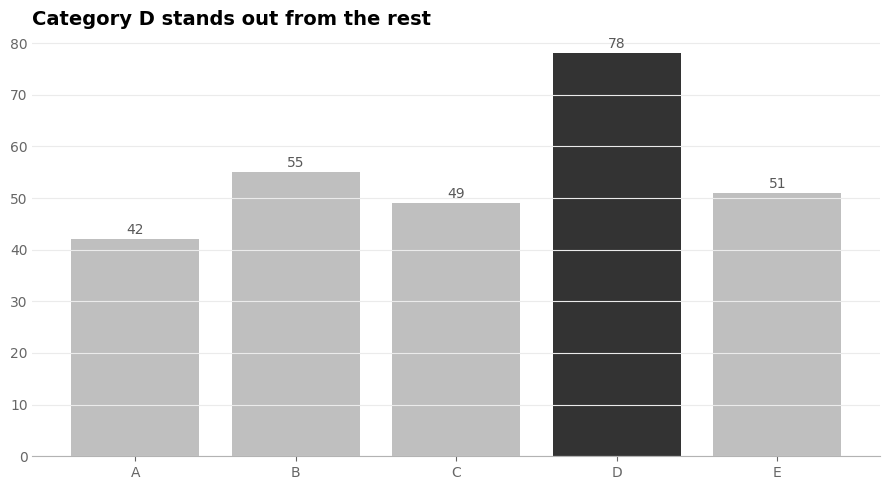

In [17]:
categories = ["A", "B", "C", "D", "E"]
values = [42, 55, 49, 78, 51]

fig, ax = plt.subplots(figsize=(9, 5))

colors = ["0.75", "0.75", "0.75", "0.2", "0.75"]  # highlight D
ax.bar(categories, values, color=colors)

ax.set_title("Category D stands out from the rest", loc="left", fontsize=14, weight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("0.7")
ax.tick_params(axis="y", length=0, colors="0.4")
ax.tick_params(axis="x", colors="0.4")
ax.grid(axis="y", color="0.92")
ax.set_ylabel("")
ax.set_xlabel("")

for i, v in enumerate(values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10, color="0.35")

plt.tight_layout()
plt.show()

In [ ]:
#I reproduced a graph in the style of the second half of Chapter 3 of Storytelling With Data by simplifying the visual, removing unnecessary clutter, using muted colors for most data, and highlighting the most important point. Rather than matching the original data exactly, I focused on recreating the overall look and feel of the graph, including its clean layout, restrained formatting, and emphasis on the main takeaway.